# IRF Convolution and Realistic TCSPC Simulation

This notebook constructs a realistic time-correlated single-photon counting
(TCSPC) simulation by combining the instrument response function (IRF),
a monoexponential fluorescence model, numerical convolution, detector
background, and Poisson photon-counting noise.

The workflow is assembled from reusable toolkit components rather than from
one specialized simulation function:

1. generate and normalize a Gaussian IRF;
2. optionally shift the IRF in time;
3. generate an ideal fluorescence decay;
4. convolve the fluorescence decay with the IRF;
5. add detector background after convolution;
6. sample measured photon counts from a Poisson distribution.

The notebook also investigates how the simulated signal depends on:

- IRF width;
- fluorescence lifetime;
- temporal alignment;
- observation-window boundaries;
- time-bin resolution.

## Learning objectives

By the end of this notebook, we will be able to:

- construct a normalized Gaussian instrument response function;
- interpret the effect of IRF normalization;
- apply positive and negative temporal shifts to an IRF;
- generate an ideal monoexponential fluorescence decay;
- convolve the fluorescence signal with the IRF;
- keep fluorescence background and detector background conceptually separate;
- generate Poisson-distributed TCSPC counts;
- identify when IRF broadening significantly distorts a lifetime measurement;
- recognize boundary, truncation, alignment, and time-bin-resolution effects.

## 1. Scientific model

An ideal monoexponential fluorescence decay is described by

$$
I_{\mathrm{fl}}(t)
=
A \exp\left(-\frac{t}{\tau}\right),
$$

where:

- $A$ is the fluorescence amplitude;
- $\tau$ is the fluorescence lifetime.

A real TCSPC instrument does not record this ideal signal directly. Its
finite temporal response broadens the fluorescence decay. The broadened signal
is represented by the convolution

$$
I_{\mathrm{conv}}(t)
=
[\mathrm{IRF} * I_{\mathrm{fl}}](t).
$$

A constant detector background is then added:

$$
\lambda(t)
=
I_{\mathrm{conv}}(t) + B,
$$

where $B$ is the expected background count level per time bin.

Finally, the measured counts are sampled according to Poisson statistics:

$$
N_i \sim \operatorname{Poisson}(\lambda_i).
$$

This notebook combines the individual toolkit components into a realistic TCSPC simulation workflow:

$$
\text{decay model}
\rightarrow
\text{IRF convolution}
\rightarrow
\text{background}
\rightarrow
\text{Poisson sampling}.
$$

The order of these operations matters. The detector background is added after
convolution because it is not fluorescence emission and therefore should not
be broadened by the instrument response. The workflow remains explicit rather
than being hidden inside a separate IRF-specific simulation function.

## 2. Imports

We use NumPy for numerical arrays, Matplotlib for visualization, and the
public TCSPC Toolkit API for decay generation, IRF processing, convolution,
and Poisson sampling.

The notebook does not reproduce the implementation of these functions. Its
purpose is to demonstrate how the existing components can be composed into a
realistic simulation workflow. The notebook uses the following TCSPC Toolkit APIs:

- `monoexponential_decay()` to generate the ideal fluorescence model;
- `generate_gaussian_irf()` to construct a Gaussian IRF;
- `normalize_irf()` to give the IRF unit area;
- `shift_irf()` to introduce a temporal offset;
- `convolve_decay_with_irf()` to model instrument broadening;
- `sample_photon_counts()` to generate Poisson-distributed measurements.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from tcspc_toolkit.convolution import convolve_decay_with_irf
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
    shift_irf,
)
from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 3. Simulation settings

We first define one common set of parameters for the main simulation.

The time interval must be long enough to include both the IRF and most of the
fluorescence decay. A fine time grid is useful because numerical convolution
and sub-bin IRF shifts depend on the temporal sampling resolution.

The fixed random seed value makes the Poisson realization reproducible.

All times in this notebook are expressed in nanoseconds.

The initial example uses:

- a 10 ns observation window;
- 1001 time points;
- a fluorescence lifetime of 1 ns;
- a Gaussian IRF with a full width at half maximum of 0.3 ns;
- a detector background of 5 expected counts per bin.

The IRF centre is placed away from the left boundary so that most of its area remains inside the observation window.

In [2]:
start_time = 0.0
end_time = 10.0
n_bins = 1001

amplitude = 1_000.0
lifetime = 1.0
background = 5.0

irf_centre = 1.0
irf_fwhm = 0.3
irf_amplitude = 1.0
irf_shift = 0.0

random_seed = 42

In [3]:
print(f"Time interval: {start_time:.2f}–{end_time:.2f} ns")
print(f"Number of bins: {n_bins}")
print(f"Fluorescence amplitude: {amplitude:.1f}")
print(f"Fluorescence lifetime: {lifetime:.2f} ns")
print(f"Detector background: {background:.2f} counts/bin")
print(f"IRF centre: {irf_centre:.2f} ns")
print(f"IRF FWHM: {irf_fwhm:.2f} ns")
print(f"Random seed: {random_seed}")

Time interval: 0.00–10.00 ns
Number of bins: 1001
Fluorescence amplitude: 1000.0
Fluorescence lifetime: 1.00 ns
Detector background: 5.00 counts/bin
IRF centre: 1.00 ns
IRF FWHM: 0.30 ns
Random seed: 42


## 4. Constructing the time axis

All arrays participating in the convolution must be sampled on the same
uniform time grid.

The time-bin width is

$$
\Delta t = t_{i+1} - t_i.
$$

A uniform grid is important because the (current) convolution implementation assumes
consistent temporal sampling. The bin width also determines how accurately
narrow IRFs and short lifetimes can be represented.

In [4]:
time = np.linspace(
    start_time,
    end_time,
    n_bins,
)

dt = time[1] - time[0]

print(f"time.shape: {time.shape}")
print(f"First time point: {time[0]:.4f} ns")
print(f"Last time point: {time[-1]:.4f} ns")
print(f"Time-bin width: {dt:.4f} ns")

time.shape: (1001,)
First time point: 0.0000 ns
Last time point: 10.0000 ns
Time-bin width: 0.0100 ns


In [5]:
assert time.ndim == 1
assert time.size == n_bins
assert np.all(np.diff(time) > 0.0)
assert np.allclose(np.diff(time), dt)

The selected grid has a bin width much smaller (30 times) than the initial IRF FWHM.
Therefore, the Gaussian IRF is represented by multiple time bins rather than
by only one or two sampled points.

## 5. Generating a Gaussian IRF

A simple instrument response can be represented by a Gaussian function
parameterized by:

- centre;
- full width at half maximum (FWHM);
- amplitude.

The raw amplitude controls the height and area of the generated Gaussian.
Before using the IRF for convolution, we will normalize its area.

In [6]:
raw_irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=irf_amplitude,
)

print(f"raw_irf.shape: {raw_irf.shape}")
print(f"Raw IRF maximum: {raw_irf.max():.6f}")
print(f"Raw IRF minimum: {raw_irf.min():.6f}")

raw_irf.shape: (1001,)
Raw IRF maximum: 1.000000
Raw IRF minimum: 0.000000


In [7]:
assert raw_irf.shape == time.shape
assert np.all(np.isfinite(raw_irf))
assert np.all(raw_irf >= 0.0)

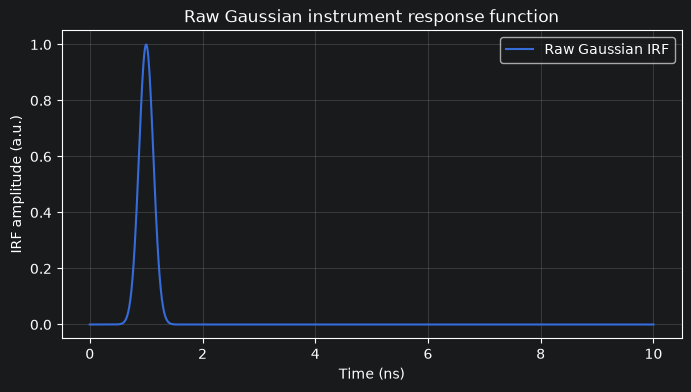

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf,
    label="Raw Gaussian IRF",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="IRF amplitude (a.u.)",
    title="Raw Gaussian instrument response function",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The centre controls the temporal location of the IRF peak, while the FWHM
controls its temporal width. At this stage, the area under the curve is not
necessarily equal to one.

## 6. Normalizing the IRF

For convolution, the IRF is treated as a temporal redistribution kernel.
Its continuous area is normalized to one:

$$
\int \mathrm{IRF}(t)\,dt = 1.
$$

After normalization, convolution redistributes the fluorescence signal in
time without introducing an arbitrary multiplicative factor determined by
the original IRF amplitude.

Normalization removes the absolute scale of the raw Gaussian. The normalized
shape still depends on the centre and FWHM.

In [9]:
normalized_irf = normalize_irf(
    time=time,
    irf=raw_irf,
)

raw_irf_area = np.trapezoid(
    raw_irf,
    x=time,
)

normalized_irf_area = np.trapezoid(
    normalized_irf,
    x=time,
)

print(f"Raw IRF area: {raw_irf_area:.6f}")
print(f"Normalized IRF area: {normalized_irf_area:.6f}")
print(f"Raw IRF maximum: {raw_irf.max():.6f}")
print(f"Normalized IRF maximum: {normalized_irf.max():.6f}")

Raw IRF area: 0.319340
Normalized IRF area: 1.000000
Raw IRF maximum: 1.000000
Normalized IRF maximum: 3.131458


In [10]:
assert normalized_irf.shape == time.shape
assert np.all(normalized_irf >= 0.0)
assert np.isclose(
    normalized_irf_area,
    1.0,
    rtol=1e-6,
    atol=1e-8,
)

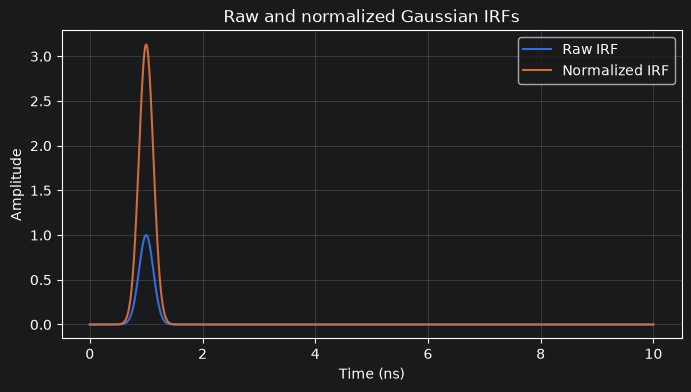

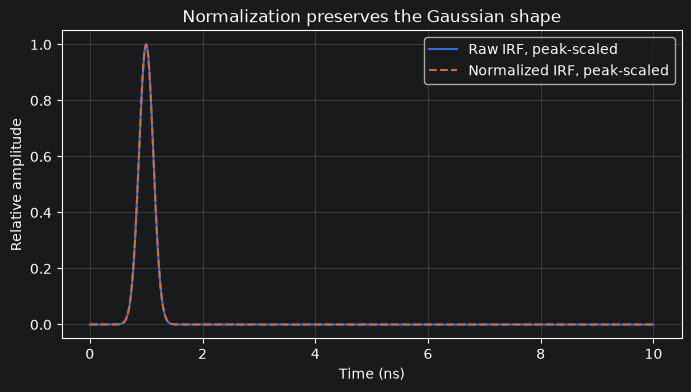

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf,
    label="Raw IRF",
)

ax.plot(
    time,
    normalized_irf,
    label="Normalized IRF",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Amplitude",
    title="Raw and normalized Gaussian IRFs",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()


raw_irf_rescaled = raw_irf / raw_irf.max()
normalized_irf_rescaled = normalized_irf / normalized_irf.max()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    raw_irf_rescaled,
    label="Raw IRF, peak-scaled",
)

ax.plot(
    time,
    normalized_irf_rescaled,
    linestyle="--",
    label="Normalized IRF, peak-scaled",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative amplitude",
    title="Normalization preserves the Gaussian shape",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The first plot shows that normalization changes the numerical scale of the
IRF. The second plot divides both curves by their maxima and confirms that
normalization does not change the Gaussian centre or FWHM.

It changes the area and peak height, but not the relative shape.

### Effect of the raw Gaussian amplitude

Two Gaussian IRFs with the same centre and FWHM but different raw amplitudes
become identical after area normalization.

The raw amplitude is therefore useful for constructing an unnormalized
function, but it does not remain as an independent physical parameter once
the IRF is normalized to unit area.

In [12]:
raw_irf_low = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=1.0,
)

raw_irf_high = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=irf_fwhm,
    amplitude=10.0,
)

normalized_irf_low = normalize_irf(
    time=time,
    irf=raw_irf_low,
)

normalized_irf_high = normalize_irf(
    time=time,
    irf=raw_irf_high,
)

maximum_difference = np.max(
    np.abs(normalized_irf_low - normalized_irf_high)
)

print(
    "Maximum difference between normalized IRFs: "
    f"{maximum_difference:.3e}"
)

np.testing.assert_allclose(
    normalized_irf_low,
    normalized_irf_high,
)

Maximum difference between normalized IRFs: 4.441e-16


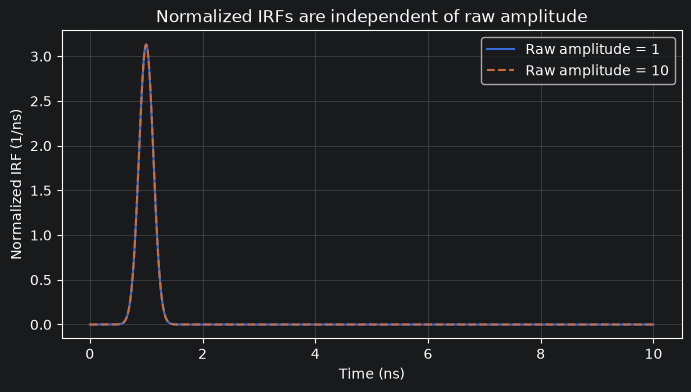

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    normalized_irf_low,
    label="Raw amplitude = 1",
)

ax.plot(
    time,
    normalized_irf_high,
    linestyle="--",
    label="Raw amplitude = 10",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Normalized IRFs are independent of raw amplitude",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 7. Applying temporal shifts

The recorded IRF and fluorescence histogram may not have perfectly aligned
time origins. A temporal shift is therefore often needed.

The shift convention used by the toolkit is

$$
\mathrm{IRF}_{\Delta t}(t)
=
\mathrm{IRF}(t-\Delta t).
$$

Consequently:

- a positive shift moves the IRF toward later times;
- a negative shift moves the IRF toward earlier times.

Interpolation permits shifts that are not integer multiples of the time-bin
width. Values outside the observed time interval are filled with zero.

In [14]:
positive_shift = 0.5
negative_shift = -0.5

irf_shifted_later = shift_irf(
    time=time,
    irf=normalized_irf,
    shift=positive_shift,
)

irf_shifted_earlier = shift_irf(
    time=time,
    irf=normalized_irf,
    shift=negative_shift,
)

print(
    "Original peak time: "
    f"{time[np.argmax(normalized_irf)]:.3f} ns"
)
print(
    "Later-shifted peak time: "
    f"{time[np.argmax(irf_shifted_later)]:.3f} ns"
)
print(
    "Earlier-shifted peak time: "
    f"{time[np.argmax(irf_shifted_earlier)]:.3f} ns"
)

Original peak time: 1.000 ns
Later-shifted peak time: 1.500 ns
Earlier-shifted peak time: 0.500 ns


In [15]:
assert irf_shifted_later.shape == time.shape
assert irf_shifted_earlier.shape == time.shape

assert (
    time[np.argmax(irf_shifted_later)]
    >
    time[np.argmax(normalized_irf)]
)

assert (
    time[np.argmax(irf_shifted_earlier)]
    <
    time[np.argmax(normalized_irf)]
)

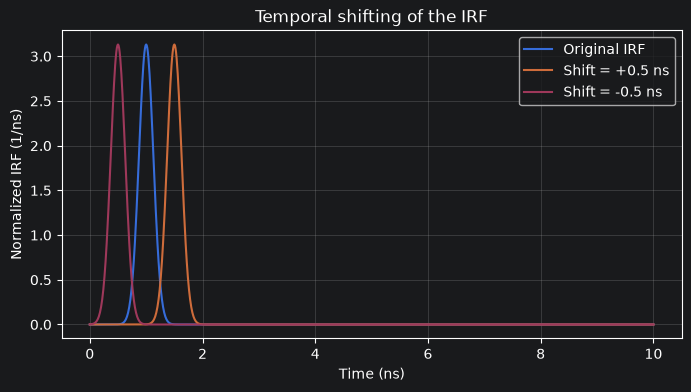

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    normalized_irf,
    label="Original IRF",
)

ax.plot(
    time,
    irf_shifted_later,
    label=f"Shift = +{positive_shift:.1f} ns",
)

ax.plot(
    time,
    irf_shifted_earlier,
    label=f"Shift = {negative_shift:.1f} ns",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Temporal shifting of the IRF",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The shifted curves retain the same general width. However, zero filling at
the time-window boundaries can remove part of an IRF if a sufficiently large
shift moves it outside the recorded interval.

For the main simulation, we will use the normalized unshifted IRF. The
boundary effect will be examined separately later.

In [17]:
irf = normalized_irf.copy()

assert irf.shape == time.shape

## 8. Generating an ideal fluorescence decay

We now generate the underlying fluorescence model without detector
background:

$$
I_{\mathrm{fl}}(t)
=
A\exp\left(-\frac{t}{\tau}\right).
$$

The background argument is explicitly set to zero because detector background
must not be included inside the signal that is convolved with the IRF.

In [18]:
ideal_fluorescence = monoexponential_decay(
    time=time,
    amplitude=amplitude,
    lifetime=lifetime,
    background=0.0,
)

print(f"ideal_fluorescence.shape: {ideal_fluorescence.shape}")
print(
    "Initial fluorescence value: "
    f"{ideal_fluorescence[0]:.3f}"
)
print(
    "Final fluorescence value: "
    f"{ideal_fluorescence[-1]:.6f}"
)

ideal_fluorescence.shape: (1001,)
Initial fluorescence value: 1000.000
Final fluorescence value: 0.045400


In [19]:
assert ideal_fluorescence.shape == time.shape
assert np.all(np.isfinite(ideal_fluorescence))
assert np.all(ideal_fluorescence >= 0.0)
assert np.isclose(
    ideal_fluorescence[0],
    amplitude,
)

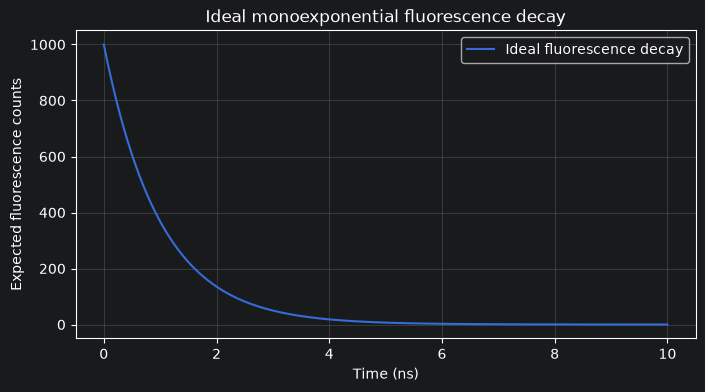

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    ideal_fluorescence,
    label="Ideal fluorescence decay",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal monoexponential fluorescence decay",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The ideal decay begins immediately at $t=0$. A real instrument response will
delay and broaden its leading edge. The convolution can therefore change both
the apparent peak position and the early-time shape.

## 9. Convolving the fluorescence decay with the IRF

The instrument-broadened fluorescence signal is calculated with

$$
I_{\mathrm{conv}}(t)
=
[\mathrm{IRF} * I_{\mathrm{fl}}](t).
$$

Both input arrays use the same time grid. The convolution implementation
returns an array aligned to the original time axis and with the same shape as
the input decay.

The time-bin width is accounted for by the convolution function so that an
area-normalized IRF behaves as a temporal redistribution kernel.

In [21]:
convolved_fluorescence = convolve_decay_with_irf(
    time=time,
    decay=ideal_fluorescence,
    irf=irf,
)

print(
    "convolved_fluorescence.shape: "
    f"{convolved_fluorescence.shape}"
)
print(
    "Maximum convolved fluorescence: "
    f"{convolved_fluorescence.max():.3f}"
)
print(
    "Time of convolved maximum: "
    f"{time[np.argmax(convolved_fluorescence)]:.3f} ns"
)

convolved_fluorescence.shape: (1001,)
Maximum convolved fluorescence: 768.725
Time of convolved maximum: 1.210 ns


In [22]:
assert convolved_fluorescence.shape == time.shape
assert np.all(np.isfinite(convolved_fluorescence))
assert np.all(convolved_fluorescence >= 0.0)


## 10. Comparing ideal and convolved fluorescence signals

The ideal and convolved curves are first compared on a linear scale. This view
emphasizes the leading edge and peak region, where IRF broadening is usually
most visible.

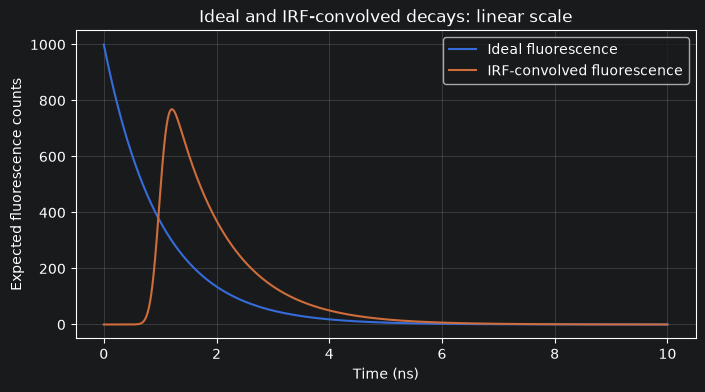

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    ideal_fluorescence,
    label="Ideal fluorescence",
)

ax.plot(
    time,
    convolved_fluorescence,
    label="IRF-convolved fluorescence",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal and IRF-convolved decays: linear scale",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The ideal model begins at its maximum at $t=0$, whereas the convolved signal
develops according to the finite temporal response of the instrument.

The convolved signal can have:

- a delayed maximum;
- a broadened leading edge;
- a reduced peak height;
- redistribution of signal into later time bins.

The exact appearance also depends on how the IRF is positioned relative to
the beginning of the time window.

A logarithmic vertical scale makes the decay tail easier to inspect. It is
especially useful for determining whether the long-time slope remains close
to the underlying monoexponential behaviour after the early-time IRF
distortion.

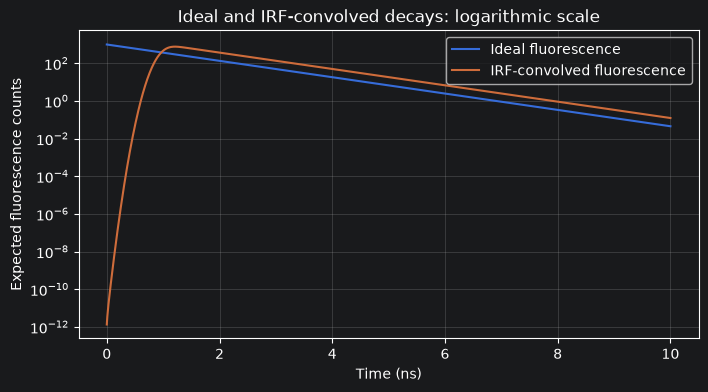

In [24]:
positive_ideal = np.maximum(
    ideal_fluorescence,
    np.finfo(float).tiny,
)

positive_convolved = np.maximum(
    convolved_fluorescence,
    np.finfo(float).tiny,
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(
    time,
    positive_ideal,
    label="Ideal fluorescence",
)

ax.semilogy(
    time,
    positive_convolved,
    label="IRF-convolved fluorescence",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected fluorescence counts",
    title="Ideal and IRF-convolved decays: logarithmic scale",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The early-time region differs strongly because it contains the IRF-induced
rise and broadening. At sufficiently late times, the convolved curve may
approach a decay slope similar to that of the underlying fluorescence model,
particularly when the lifetime is much longer than the IRF width.

## 11. Adding detector background

A constant detector background is added after convolution:

$$
\lambda(t)
=
I_{\mathrm{conv}}(t) + B.
$$

This ordering is physically important. If the background were included in
the ideal decay before convolution, the convolution operation would broaden
or distort a signal component that is supposed to remain constant across
time bins.

In [25]:
expected_counts = convolved_fluorescence + background

print(f"expected_counts.shape: {expected_counts.shape}")
print(
    "Minimum expected count value: "
    f"{expected_counts.min():.6f}"
)
print(
    "Final expected count value: "
    f"{expected_counts[-1]:.6f}"
)

expected_counts.shape: (1001,)
Minimum expected count value: 5.000000
Final expected count value: 5.124415


In [26]:
assert expected_counts.shape == time.shape
assert np.all(np.isfinite(expected_counts))
assert np.all(expected_counts >= 0.0)

np.testing.assert_allclose(
    expected_counts - convolved_fluorescence,
    background,
)

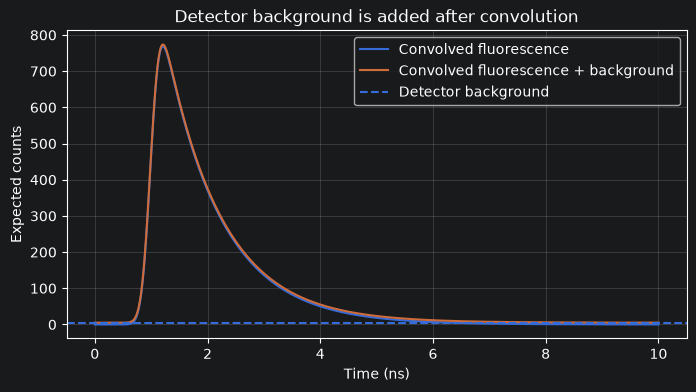

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    convolved_fluorescence,
    label="Convolved fluorescence",
)

ax.plot(
    time,
    expected_counts,
    label="Convolved fluorescence + background",
)

ax.axhline(
    background,
    linestyle="--",
    label="Detector background",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected counts",
    title="Detector background is added after convolution",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

At late times, the fluorescence contribution becomes small and the expected
signal approaches the detector-background level.

The difference between the two plotted curves is constant and equal to
$B$ in every time bin.

### Why background must not be convolved

For demonstration only, we compare the correct model with an intentionally
incorrect sequence in which the background is inserted before convolution.

The incorrect curve is not used elsewhere in the notebook.

In [28]:
incorrect_decay_with_background = monoexponential_decay(
    time=time,
    amplitude=amplitude,
    lifetime=lifetime,
    background=background,
)

incorrect_expected_counts = convolve_decay_with_irf(
    time=time,
    decay=incorrect_decay_with_background,
    irf=irf,
)

correct_expected_counts = (
    convolve_decay_with_irf(
        time=time,
        decay=ideal_fluorescence,
        irf=irf,
    )
    + background
)

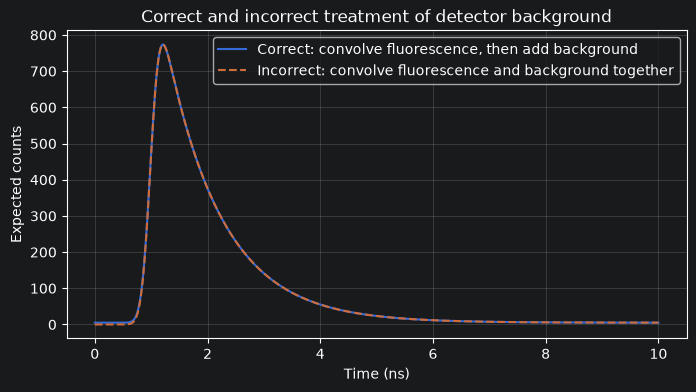

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    correct_expected_counts,
    label="Correct: convolve fluorescence, then add background",
)

ax.plot(
    time,
    incorrect_expected_counts,
    linestyle="--",
    label="Incorrect: convolve fluorescence and background together",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Expected counts",
    title="Correct and incorrect treatment of detector background",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The incorrect ordering can create a boundary-dependent background contribution
because the finite-window convolution does not treat a constant array as an
unchanged infinite constant signal.

The correct model keeps the detector baseline independent of IRF broadening.

## 12. Poisson sampling

The expected curve $\lambda(t)$ describes the mean count value in every time
bin. A measured TCSPC histogram fluctuates around this expectation.

For independent photon-counting bins:

$$
N_i \sim \operatorname{Poisson}(\lambda_i).
$$

The variance of a Poisson-distributed count is equal to its expectation:

$$
\operatorname{Var}(N_i)=\lambda_i.
$$

Therefore, high-count bins have larger absolute fluctuations but smaller
relative fluctuations than low-count bins.

In [30]:
rng = np.random.default_rng(random_seed)

measured_counts = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng,
)

print(f"measured_counts.shape: {measured_counts.shape}")
print(f"Measured dtype: {measured_counts.dtype}")
print(f"Total expected counts: {expected_counts.sum():.1f}")
print(f"Total measured counts: {measured_counts.sum()}")

measured_counts.shape: (1001,)
Measured dtype: int64
Total expected counts: 105493.5
Total measured counts: 105394


In [31]:
assert measured_counts.shape == time.shape
assert np.issubdtype(
    measured_counts.dtype,
    np.integer,
)
assert np.all(measured_counts >= 0)

In [32]:
rng_first = np.random.default_rng(random_seed)
rng_second = np.random.default_rng(random_seed)

measured_counts_first = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng_first,
)

measured_counts_second = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng_second,
)

np.testing.assert_array_equal(
    measured_counts_first,
    measured_counts_second,
)

print("Repeated sampling with the same seed is reproducible.")

Repeated sampling with the same seed is reproducible.


The fixed seed is useful for notebook reproducibility and automated testing.
It does not remove the Poisson nature of the simulated measurement; it only
selects the same pseudorandom realization each time the notebook is executed.

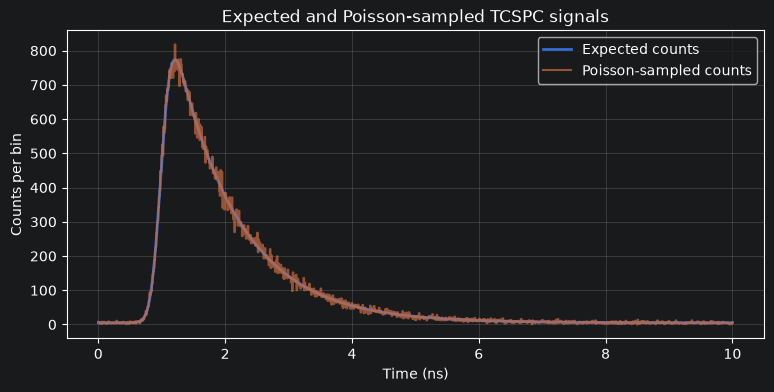

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    time,
    expected_counts,
    linewidth=2,
    label="Expected counts",
)

ax.step(
    time,
    measured_counts,
    where="mid",
    alpha=0.7,
    label="Poisson-sampled counts",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Counts per bin",
    title="Expected and Poisson-sampled TCSPC signals",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The sampled histogram fluctuates around the expected curve. The fluctuations
are most visibly different across regions with different mean count levels.

The expected curve is continuous-valued because it represents the Poisson
mean, while the sampled histogram contains non-negative integer counts.

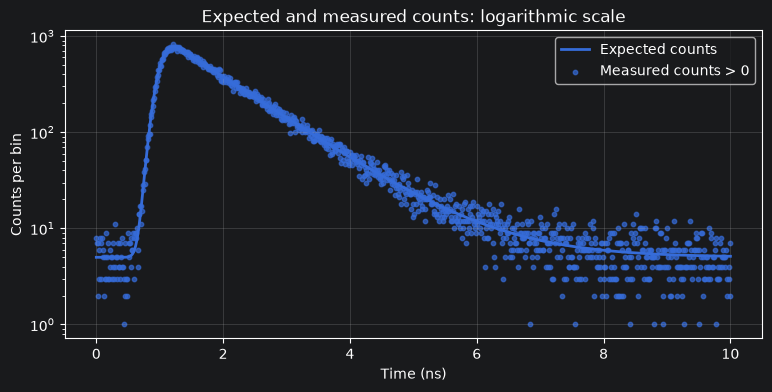

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogy(
    time,
    np.maximum(
        expected_counts,
        np.finfo(float).tiny,
    ),
    linewidth=2,
    label="Expected counts",
)

positive_measured_mask = measured_counts > 0

ax.scatter(
    time[positive_measured_mask],
    measured_counts[positive_measured_mask],
    s=10,
    alpha=0.7,
    label="Measured counts > 0",
)

ax.set(
    xlabel="Time (ns)",
    ylabel="Counts per bin",
    title="Expected and measured counts: logarithmic scale",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

Zero measured counts cannot be displayed directly on a logarithmic axis.
Therefore, only positive measured bins are shown as points.

The background prevents the expected curve from approaching zero and produces
a late-time baseline.

## 13. Complete realistic simulation pipeline

The main workflow can now be summarized as:

```python
ideal_fluorescence = monoexponential_decay(
    time=time,
    amplitude=amplitude,
    lifetime=lifetime,
    background=0.0,
)

convolved_fluorescence = convolve_decay_with_irf(
    time=time,
    decay=ideal_fluorescence,
    irf=irf,
)

expected_counts = convolved_fluorescence + background

rng = np.random.default_rng(random_seed)
measured_counts = sample_photon_counts(
    expected_counts=expected_counts,
    rng=rng,
)
```

Each operation has one clear responsibility:

`monoexponential_decay()` defines the fluorescence model;
`convolve_decay_with_irf()` models the temporal response of the instrument;
addition of background models the detector baseline;
`sample_photon_counts()` models photon-counting noise.

This compositional API can later be reused with biexponential or
multiexponential decay models without introducing a separate simulation
wrapper for every decay-model and IRF combination.

## 14. Influence of IRF width

We now keep the fluorescence lifetime fixed and vary the IRF FWHM.

A broader IRF spreads the signal over a longer temporal interval. This is
particularly important when the fluorescence lifetime is comparable to or
shorter than the IRF width.

In [35]:
width_experiment_lifetime = 0.5

irf_widths = [
    0.05,
    0.10,
    0.30,
    0.60,
]

width_experiment_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=width_experiment_lifetime,
    background=0.0,
)

In [36]:
convolved_by_width = {}

for width in irf_widths:
    experiment_irf = generate_gaussian_irf(
        time=time,
        centre=irf_centre,
        fwhm=width,
        amplitude=1.0,
    )

    experiment_irf = normalize_irf(
        time=time,
        irf=experiment_irf,
    )

    convolved_by_width[width] = convolve_decay_with_irf(
        time=time,
        decay=width_experiment_decay,
        irf=experiment_irf,
    )

In [37]:
for width, curve in convolved_by_width.items():
    assert curve.shape == time.shape
    assert np.all(np.isfinite(curve))
    assert np.all(curve >= 0.0)

print(
    f"Generated {len(convolved_by_width)} "
    "IRF-width comparison curves."
)

Generated 4 IRF-width comparison curves.


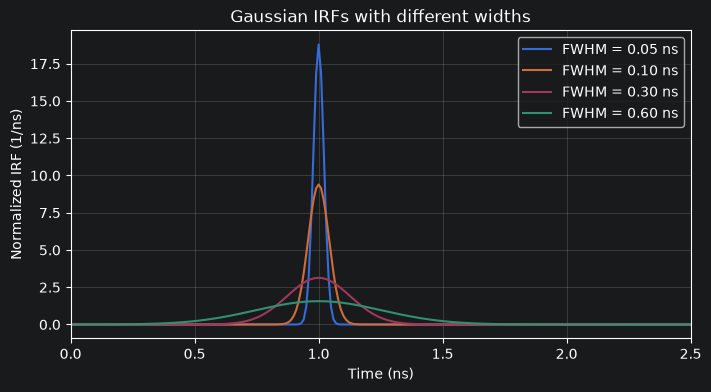

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))

for width in irf_widths:
    experiment_irf = generate_gaussian_irf(
        time=time,
        centre=irf_centre,
        fwhm=width,
        amplitude=1.0,
    )

    experiment_irf = normalize_irf(
        time=time,
        irf=experiment_irf,
    )

    ax.plot(
        time,
        experiment_irf,
        label=f"FWHM = {width:.2f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Gaussian IRFs with different widths",
)

ax.set_xlim(
    irf_centre - 1.0,
    irf_centre + 1.5,
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

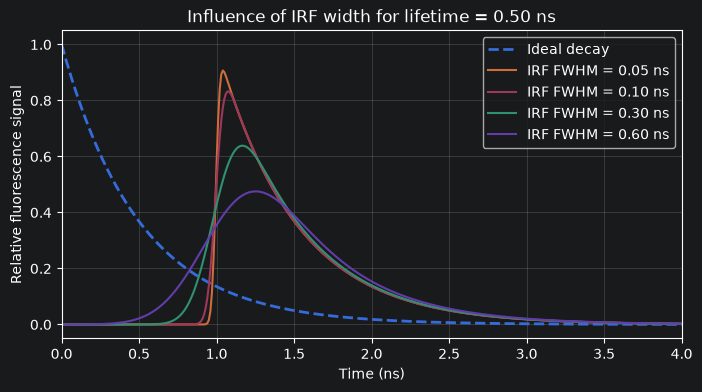

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    time,
    width_experiment_decay,
    linestyle="--",
    linewidth=2,
    label="Ideal decay",
)

for width, curve in convolved_by_width.items():
    ax.plot(
        time,
        curve,
        label=f"IRF FWHM = {width:.2f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative fluorescence signal",
    title=(
        "Influence of IRF width "
        f"for lifetime = {width_experiment_lifetime:.2f} ns"
    ),
)

ax.set_xlim(0.0, 4.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

As the IRF becomes wider:

- the leading edge becomes more gradual;
- the signal maximum can move to later times;
- the peak becomes broader;
- short-time decay information becomes less directly visible.

A very narrow normalized IRF approaches an impulse-like response, so its
convolution approaches the ideal decay, subject to the discrete time grid and
array alignment.

In [40]:
width_summary = []

for width, curve in convolved_by_width.items():
    peak_index = np.argmax(curve)

    width_summary.append(
        (
            width,
            time[peak_index],
            curve[peak_index],
        )
    )

print("FWHM (ns) | Peak time (ns) | Peak value")
print("-" * 43)

for width, peak_time, peak_value in width_summary:
    print(
        f"{width:9.2f} | "
        f"{peak_time:14.3f} | "
        f"{peak_value:10.4f}"
    )

FWHM (ns) | Peak time (ns) | Peak value
-------------------------------------------
     0.05 |          1.040 |     0.9073
     0.10 |          1.070 |     0.8324
     0.30 |          1.170 |     0.6385
     0.60 |          1.250 |     0.4754


## 15. Influence of fluorescence lifetime

We now use one fixed IRF with

$$
\mathrm{FWHM}_{\mathrm{IRF}} = 0.3\ \mathrm{ns}
$$

and compare the lifetimes

$$
\tau = [0.1,\ 0.5,\ 1.0,\ 3.0]\ \mathrm{ns}.
$$

The ratio

$$
\frac{\tau}{\mathrm{FWHM}_{\mathrm{IRF}}}
$$

provides a simple indication of how strongly the temporal response of the
instrument competes with the intrinsic fluorescence timescale.

In [41]:
lifetime_experiment_values = [
    0.1,
    0.5,
    1.0,
    3.0,
]

lifetime_experiment_irf_fwhm = 0.3

lifetime_experiment_irf = generate_gaussian_irf(
    time=time,
    centre=irf_centre,
    fwhm=lifetime_experiment_irf_fwhm,
    amplitude=1.0,
)

lifetime_experiment_irf = normalize_irf(
    time=time,
    irf=lifetime_experiment_irf,
)

In [42]:
assert np.isclose(
    np.trapezoid(
        lifetime_experiment_irf,
        x=time,
    ),
    1.0,
    rtol=1e-6,
    atol=1e-8,
)

In [43]:
ideal_by_lifetime = {}
convolved_by_lifetime = {}

for current_lifetime in lifetime_experiment_values:
    current_ideal = monoexponential_decay(
        time=time,
        amplitude=1.0,
        lifetime=current_lifetime,
        background=0.0,
    )

    current_convolved = convolve_decay_with_irf(
        time=time,
        decay=current_ideal,
        irf=lifetime_experiment_irf,
    )

    ideal_by_lifetime[current_lifetime] = current_ideal
    convolved_by_lifetime[current_lifetime] = current_convolved

In [44]:
for current_lifetime in lifetime_experiment_values:
    assert (
        ideal_by_lifetime[current_lifetime].shape
        == time.shape
    )

    assert (
        convolved_by_lifetime[current_lifetime].shape
        == time.shape
    )

In [45]:
print("Lifetime (ns) | tau / IRF FWHM | Interpretation")
print("-" * 68)

for current_lifetime in lifetime_experiment_values:
    ratio = (
        current_lifetime
        / lifetime_experiment_irf_fwhm
    )

    if ratio < 1.0:
        interpretation = "Lifetime shorter than IRF width"
    elif ratio < 3.0:
        interpretation = "Comparable timescales"
    else:
        interpretation = "Lifetime longer than IRF width"

    print(
        f"{current_lifetime:13.2f} | "
        f"{ratio:14.2f} | "
        f"{interpretation}"
    )

Lifetime (ns) | tau / IRF FWHM | Interpretation
--------------------------------------------------------------------
         0.10 |           0.33 | Lifetime shorter than IRF width
         0.50 |           1.67 | Comparable timescales
         1.00 |           3.33 | Lifetime longer than IRF width
         3.00 |          10.00 | Lifetime longer than IRF width


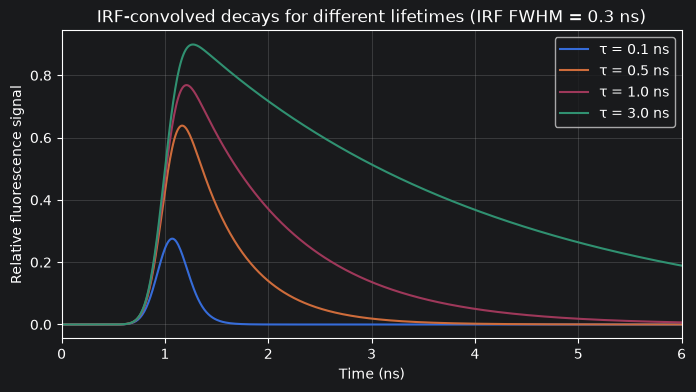

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_lifetime in lifetime_experiment_values:
    ax.plot(
        time,
        convolved_by_lifetime[current_lifetime],
        label=f"τ = {current_lifetime:.1f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative fluorescence signal",
    title=(
        "IRF-convolved decays for different lifetimes "
        f"(IRF FWHM = {lifetime_experiment_irf_fwhm:.1f} ns)"
    ),
)

ax.set_xlim(0.0, 6.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

For the shortest lifetime, the intrinsic fluorescence decay occurs on a
timescale shorter than the IRF width. The recorded leading edge and peak shape
are therefore strongly controlled by the instrument response.

For the longest lifetime, the IRF still affects the early-time region, but
the slower fluorescence decay dominates a much larger part of the observed
signal.

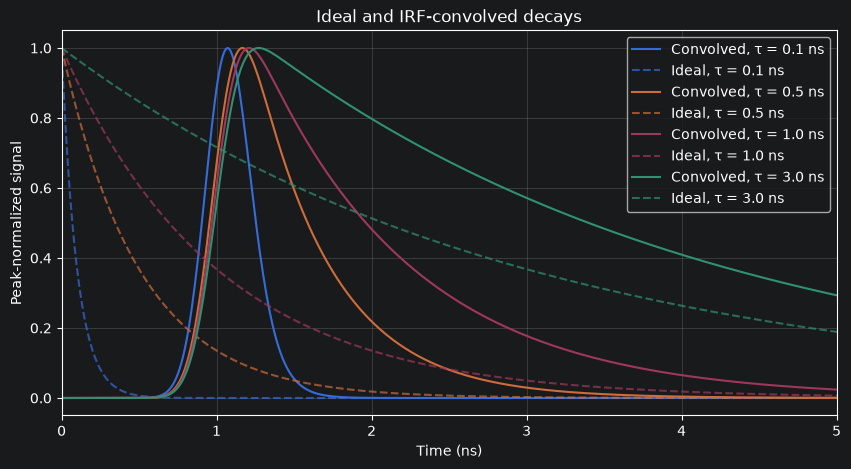

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

for current_lifetime in lifetime_experiment_values:
    ideal_curve = ideal_by_lifetime[current_lifetime]
    convolved_curve = convolved_by_lifetime[current_lifetime]

    ideal_peak_normalized = (
        ideal_curve
        / ideal_curve.max()
    )

    convolved_peak_normalized = (
        convolved_curve
        / convolved_curve.max()
    )

    convolved_line, = ax.plot(
        time,
        convolved_peak_normalized,
        label=f"Convolved, τ = {current_lifetime:.1f} ns",
    )

    ax.plot(
        time,
        ideal_peak_normalized,
        linestyle="--",
        color=convolved_line.get_color(),
        alpha=0.7,
        label=f"Ideal, τ = {current_lifetime:.1f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Peak-normalized signal",
    title="Ideal and IRF-convolved decays",
)

ax.set_xlim(0.0, 5.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

Peak normalization is used here only to compare temporal shapes. It removes
the direct information about absolute expected counts.

The comparison demonstrates that:

- for $\tau < \mathrm{FWHM}_{\mathrm{IRF}}$, the observed curve can be
  strongly IRF dominated;
- for comparable timescales, IRF effects remain central to interpretation;
- for $\tau \gg \mathrm{FWHM}_{\mathrm{IRF}}$, distortion is concentrated
  more strongly in the early-time region.

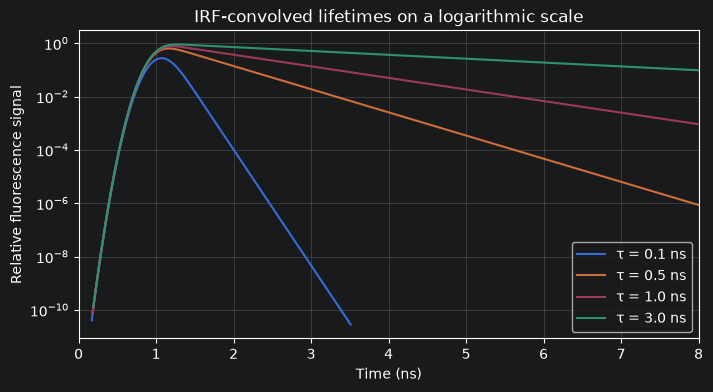

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_lifetime in lifetime_experiment_values:
    curve = convolved_by_lifetime[current_lifetime]

    threshold = curve.max() * 1e-10

    curve_for_log = np.where(
        curve > threshold,
        curve,
        np.nan,
    )

    ax.semilogy(
        time,
        curve_for_log,
        label=f"τ = {current_lifetime:.1f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative fluorescence signal",
    title="IRF-convolved lifetimes on a logarithmic scale",
)

ax.set_xlim(0.0, 8.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

The logarithmic plot emphasizes the different long-time slopes. Although the
IRF can dominate the leading edge of a short-lifetime signal, the decay tail
contains lifetime-dependent information when enough signal remains above the
background and noise level.

## 16. Influence of IRF temporal alignment

A temporal mismatch between the measured IRF and decay histogram changes the
position and shape of the convolved signal.

We compare several IRF shifts while keeping the fluorescence model fixed.

In [49]:
alignment_shifts = [
    -0.2,
    0.0,
    0.2,
    0.5,
]

alignment_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=0.5,
    background=0.0,
)

convolved_by_shift = {}

for current_shift in alignment_shifts:
    current_irf = shift_irf(
        time=time,
        irf=lifetime_experiment_irf,
        shift=current_shift,
    )

    convolved_by_shift[current_shift] = (
        convolve_decay_with_irf(
            time=time,
            decay=alignment_decay,
            irf=current_irf,
        )
    )

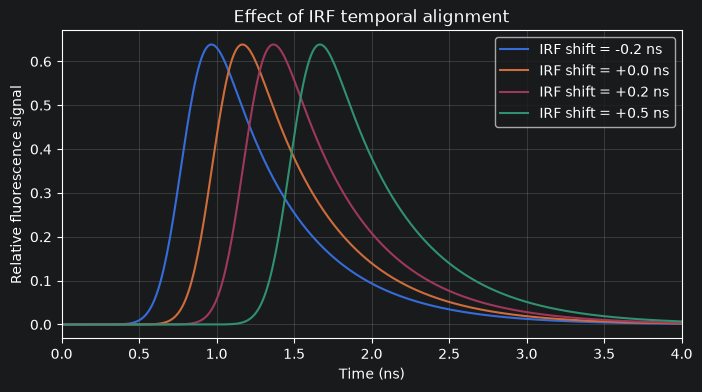

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_shift, curve in convolved_by_shift.items():
    ax.plot(
        time,
        curve,
        label=f"IRF shift = {current_shift:+.1f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative fluorescence signal",
    title="Effect of IRF temporal alignment",
)

ax.set_xlim(0.0, 4.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

A positive IRF shift moves the instrument-broadened response toward later
times. In reconvolution fitting, an incorrect temporal offset can therefore
bias the fitted lifetime or degrade the agreement between the model and
measurement.

This is why the shift convention must be documented and tested explicitly.

## 17. Boundary and truncation effects

The time axis represents only a finite observation window. If part of the IRF
lies outside this interval, that part cannot participate in the numerical
convolution.

For example, an IRF centred too close to the beginning of the time axis may
be truncated on its left side. A large temporal shift can also move part of a
previously normalized IRF outside the window.

If the shifted IRF is not renormalized, its remaining area can become smaller
than one. This represents loss caused by truncation.

In [51]:
boundary_shifts = [
    -1.2,
    -0.8,
    0.0,
    7.5,
]

boundary_irfs = {}
boundary_areas = {}

for current_shift in boundary_shifts:
    current_irf = shift_irf(
        time=time,
        irf=normalized_irf,
        shift=current_shift,
    )

    boundary_irfs[current_shift] = current_irf

    boundary_areas[current_shift] = np.trapezoid(
        current_irf,
        x=time,
    )

In [52]:
print("Shift (ns) | Remaining IRF area")
print("-" * 32)

for current_shift, area in boundary_areas.items():
    print(
        f"{current_shift:10.2f} | "
        f"{area:18.6f}"
    )

Shift (ns) | Remaining IRF area
--------------------------------
     -1.20 |           0.058315
     -0.80 |           0.941685
      0.00 |           1.000000
      7.50 |           1.000000


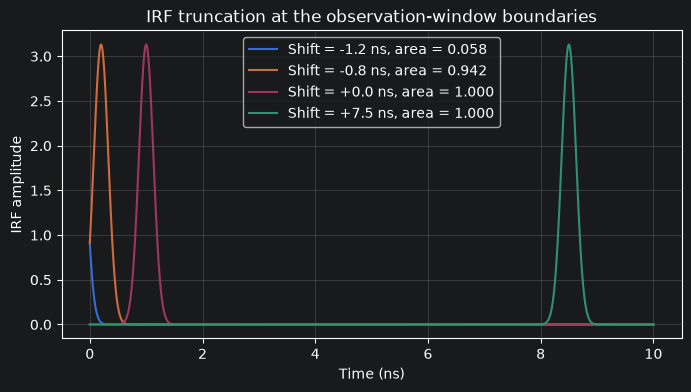

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_shift, current_irf in boundary_irfs.items():
    ax.plot(
        time,
        current_irf,
        label=(
            f"Shift = {current_shift:+.1f} ns, "
            f"area = {boundary_areas[current_shift]:.3f}"
        ),
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="IRF amplitude",
    title="IRF truncation at the observation-window boundaries",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

The unshifted IRF remains fully inside the time window and retains an area
close to one. Strongly shifted IRFs lose area when part of their shape moves
outside the recorded interval.

Whether a truncated shifted IRF should be renormalized depends on the intended
physical model:

- preserving the reduced area represents signal loss outside the window;
- renormalizing preserves unit area but changes the interpretation by
  redistributing only the retained part.

The current `shift_irf()` behaviour preserves truncation rather than
renormalizing automatically.

In [54]:
boundary_decay = monoexponential_decay(
    time=time,
    amplitude=1.0,
    lifetime=1.0,
    background=0.0,
)

boundary_convolved = {}

for current_shift, current_irf in boundary_irfs.items():
    boundary_convolved[current_shift] = (
        convolve_decay_with_irf(
            time=time,
            decay=boundary_decay,
            irf=current_irf,
        )
    )

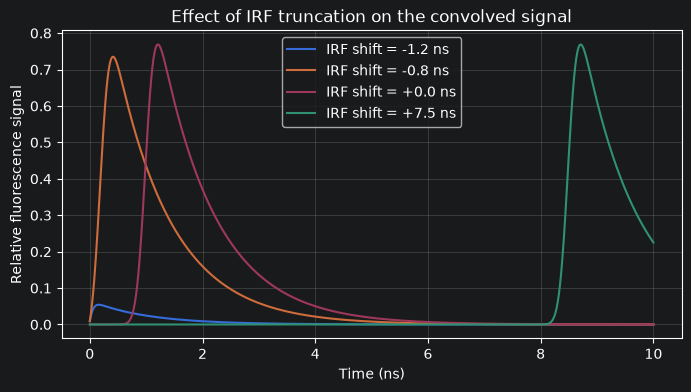

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_shift, curve in boundary_convolved.items():
    ax.plot(
        time,
        curve,
        label=f"IRF shift = {current_shift:+.1f} ns",
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Relative fluorescence signal",
    title="Effect of IRF truncation on the convolved signal",
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

A truncated IRF can change not only the temporal position of the convolved
signal but also its overall scale because the retained IRF area may be less
than one.

This is a finite-window effect rather than a property of the ideal continuous
convolution over an infinite time domain.

## 18. Time-bin resolution experiment

The numerical representation of an IRF depends on the time-bin width.

A coarse grid may sample a narrow Gaussian using only a few points. This can
affect:

- the estimated IRF area;
- the peak position;
- the apparent width;
- the accuracy of temporal shifts;
- the numerical convolution.

We compare the same physical model on several uniform time grids.

In [56]:
resolution_bin_counts = [
    101,
    501,
    1001,
    5001,
]

resolution_irf_fwhm = 0.1
resolution_lifetime = 0.5

resolution_results = {}

In [57]:
for current_n_bins in resolution_bin_counts:
    current_time = np.linspace(
        start_time,
        end_time,
        current_n_bins,
    )

    current_dt = (
        current_time[1]
        - current_time[0]
    )

    current_irf = generate_gaussian_irf(
        time=current_time,
        centre=irf_centre,
        fwhm=resolution_irf_fwhm,
        amplitude=1.0,
    )

    current_irf = normalize_irf(
        time=current_time,
        irf=current_irf,
    )

    current_decay = monoexponential_decay(
        time=current_time,
        amplitude=1.0,
        lifetime=resolution_lifetime,
        background=0.0,
    )

    current_convolved = convolve_decay_with_irf(
        time=current_time,
        decay=current_decay,
        irf=current_irf,
    )

    resolution_results[current_n_bins] = {
        "time": current_time,
        "dt": current_dt,
        "irf": current_irf,
        "decay": current_decay,
        "convolved": current_convolved,
    }

In [58]:
print("Number of bins | Bin width (ns) | FWHM / bin width")
print("-" * 57)

for current_n_bins, result in resolution_results.items():
    bins_across_fwhm = (
        resolution_irf_fwhm
        / result["dt"]
    )

    print(
        f"{current_n_bins:14d} | "
        f"{result['dt']:14.5f} | "
        f"{bins_across_fwhm:16.2f}"
    )

Number of bins | Bin width (ns) | FWHM / bin width
---------------------------------------------------------
           101 |        0.10000 |             1.00
           501 |        0.02000 |             5.00
          1001 |        0.01000 |            10.00
          5001 |        0.00200 |            50.00


The ratio between the IRF FWHM and the bin width indicates approximately how
many time-bin intervals span the IRF width.

When this ratio is small, the IRF is poorly resolved by the grid.

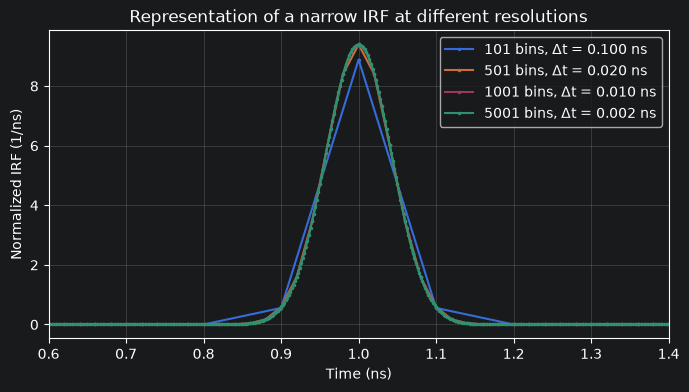

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_n_bins, result in resolution_results.items():
    ax.plot(
        result["time"],
        result["irf"],
        marker=".",
        markersize=3,
        label=(
            f"{current_n_bins} bins, "
            f"Δt = {result['dt']:.3f} ns"
        ),
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Normalized IRF (1/ns)",
    title="Representation of a narrow IRF at different resolutions",
)

ax.set_xlim(
    irf_centre - 0.4,
    irf_centre + 0.4,
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

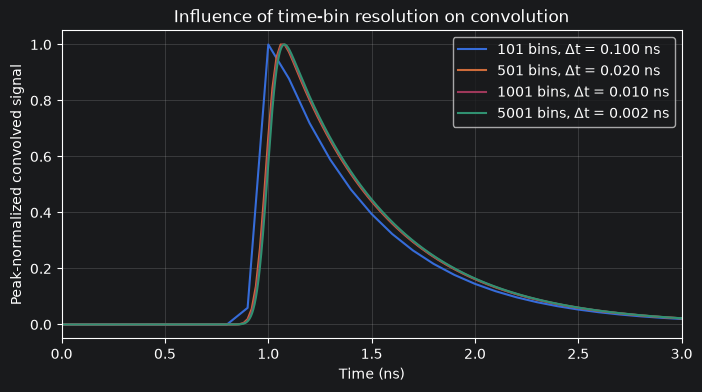

In [60]:
fig, ax = plt.subplots(figsize=(8, 4))

for current_n_bins, result in resolution_results.items():
    normalized_curve = (
        result["convolved"]
        / result["convolved"].max()
    )

    ax.plot(
        result["time"],
        normalized_curve,
        label=(
            f"{current_n_bins} bins, "
            f"Δt = {result['dt']:.3f} ns"
        ),
    )

ax.set(
    xlabel="Time (ns)",
    ylabel="Peak-normalized convolved signal",
    title="Influence of time-bin resolution on convolution",
)

ax.set_xlim(0.0, 3.0)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

As the time grid becomes finer, the sampled IRF and convolved curve should
approach a stable numerical result.

A visibly different coarse-grid result indicates that the selected bin width
is not sufficient to represent the fastest timescale in the model.

Time-bin refinement does not create new experimental information, but it is
necessary for accurately representing the assumed continuous model
numerically.

## 19. Integration checks

The notebook uses several independently tested functions. We now perform a
small integration check of the complete realistic simulation pipeline.

These assertions do not replace the package test suite. They verify that the
functions work together as expected in this notebook.

In [61]:
integration_decay = monoexponential_decay(
    time=time,
    amplitude=500.0,
    lifetime=1.5,
    background=0.0,
)

integration_irf = generate_gaussian_irf(
    time=time,
    centre=1.0,
    fwhm=0.25,
    amplitude=1.0,
)

integration_irf = normalize_irf(
    time=time,
    irf=integration_irf,
)

integration_convolved = convolve_decay_with_irf(
    time=time,
    decay=integration_decay,
    irf=integration_irf,
)

integration_expected = (
    integration_convolved
    + 3.0
)

integration_seed = 123
integration_rng = np.random.default_rng(integration_seed)
integration_measured = sample_photon_counts(
    expected_counts=integration_expected,
    rng=integration_rng,
)

In [62]:
assert integration_decay.shape == time.shape
assert integration_irf.shape == time.shape
assert integration_convolved.shape == time.shape
assert integration_expected.shape == time.shape
assert integration_measured.shape == time.shape

assert np.all(integration_irf >= 0.0)
assert np.all(integration_convolved >= 0.0)
assert np.all(integration_expected >= 0.0)
assert np.all(integration_measured >= 0)

assert np.isclose(
    np.trapezoid(
        integration_irf,
        x=time,
    ),
    1.0,
    rtol=1e-6,
    atol=1e-8,
)

np.testing.assert_allclose(
    integration_expected
    - integration_convolved,
    3.0,
)

print("The complete simulation pipeline passed all integration checks.")

The complete simulation pipeline passed all integration checks.


## 20. Discussion

This notebook assembled a realistic TCSPC simulation from separate toolkit
components:

1. a monoexponential fluorescence model;
2. a normalized Gaussian IRF;
3. numerical convolution;
4. a constant detector background;
5. Poisson photon-counting noise.

The results illustrate several important points.

### IRF normalization

An area-normalized IRF acts as a temporal redistribution kernel. The original
Gaussian amplitude does not remain as an independent scale factor after
normalization.

### IRF width

A broader IRF produces stronger temporal broadening. Its influence becomes
especially important when the fluorescence lifetime is comparable to or
shorter than the IRF FWHM.

### Fluorescence lifetime

For long lifetimes, the IRF primarily modifies the leading edge and peak
region. For short lifetimes, the observed signal can be dominated by the
instrument response over much of its measurable duration.

### Temporal alignment

Shifting the IRF changes the temporal position of the convolved signal.
Incorrect alignment can therefore affect lifetime estimation during
reconvolution fitting.

### Detector background

The detector background must be added after convolution. It represents a
constant expected baseline and is not part of the fluorescence signal
broadened by the IRF.

### Finite observation windows

Temporal shifts can move part of an IRF outside the recorded interval.
Truncation may reduce its area and consequently alter the scale of the
convolved signal.

### Time-bin resolution

The time grid must resolve both the IRF and the fluorescence decay. A narrow
IRF represented by only a few bins can lead to inaccurate numerical results.

## 21. Limitations and future work

The simulation in this notebook is intentionally simplified.

Current limitations include:

- a Gaussian approximation for the IRF;
- a monoexponential fluorescence model;
- a constant detector background;
- independent Poisson sampling in every time bin;
- a finite non-periodic observation window;
- no detector pile-up model;
- no afterpulsing;
- no timing jitter beyond the selected IRF;
- no reconvolution-based parameter fitting;
- no uncertainty estimation.

Future development can extend the same compositional workflow to:

- biexponential and multiexponential decays;
- measured or asymmetric IRFs;
- fitted temporal IRF offsets;
- reconvolution fitting;
- likelihood-based parameter estimation;
- realistic acquisition artifacts;
- synthetic datasets for machine-learning experiments.

## 22. Conclusions

A realistic TCSPC simulation does not require one specialized
`simulate_irf_convolved_decay()` function.

Instead, the simulation is built by composing functions with clear,
independent responsibilities:

```text
monoexponential_decay()
        ↓
convolve_decay_with_irf()
        ↓
add detector background
        ↓
sample_photon_counts()
```

This design keeps the scientific model explicit and makes the same
convolution and sampling operations reusable with future decay models.

The central physical conclusion is that the importance of the IRF depends on
the relationship between the fluorescence lifetime and the temporal width of
the instrument response. When the lifetime is short relative to the IRF
FWHM, the recorded signal cannot be interpreted as an undistorted exponential
decay.

In [63]:
required_arrays = {
    "time": time,
    "raw_irf": raw_irf,
    "normalized_irf": normalized_irf,
    "ideal_fluorescence": ideal_fluorescence,
    "convolved_fluorescence": convolved_fluorescence,
    "expected_counts": expected_counts,
    "measured_counts": measured_counts,
}

for name, array in required_arrays.items():
    assert array.shape == time.shape
    assert np.all(np.isfinite(array))

assert np.all(raw_irf >= 0.0)
assert np.all(normalized_irf >= 0.0)
assert np.all(ideal_fluorescence >= 0.0)
assert np.all(convolved_fluorescence >= 0.0)
assert np.all(expected_counts >= 0.0)
assert np.all(measured_counts >= 0)

print("Notebook verification completed successfully.")

Notebook verification completed successfully.
